# eq_IO_PR_bias: Zonal structure of time-mean PR in the equatorial Indian Ocean


Computes the zonal root mean square error (RMSE) of equatorial Indian (50°E-110°E) climatological (time and meridional 10°S-10°N average) precipitation (PR) between model and observations


## Datasets and reanalysis used for comparison

The following reference observational datasets are used to evaluate the model simulations:

- **GPCPv2.3 (1979-2018)**: The primary dataset for comparison. The Global Precipitation Climatology Project (GPCP) combines satellite and surface precipitation measurements to provide comprehensive global precipitation data.
  
Additional observational datasets used for comparison include:
- **20CRv2 (1871-2012)**: The 20th Century Reanalysis provides global atmospheric data, including precipitation, based on surface pressure observations and ensemble assimilation techniques.
- **CMAP (1979-2018)**: The CPC Merged Analysis of Precipitation (CMAP) is a blend of gauge and satellite observations, offering global precipitation estimates.
- **ERA-Interim (1979-2018)**: Reanalysis data produced by the European Centre for Medium-Range Weather Forecasts (ECMWF), providing atmospheric variables, including precipitation, based on a large-scale model and historical observations.
- **NCEP2 (1979-2018)**: The second generation of the National Centers for Environmental Prediction (NCEP) reanalysis, offering precipitation and other atmospheric variables.

## Dask Cluster 

Start a cluster with multiple cores 

In [1]:
from dask.distributed import Client, progress
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 28,Total memory: 126.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43431,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46289,Total threads: 4
Dashboard: /proxy/45013/status,Memory: 18.00 GiB
Nanny: tcp://127.0.0.1:39873,


## Datasets

In [2]:
from esmvalcore.dataset import Dataset

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/esmvalcore/config/_config_object.py:639: ESMValCoreDeprecationWarning: Usage of the single configuration file ~/.esmvaltool/config-user.yml or specifying it via CLI argument `--config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please run `mkdir -p ~/.config/esmvaltool && mv /home/548/cxc548/.esmvaltool/config-user.yml ~/.config/esmvaltool` (or alternatively use a custom `--config_dir`) and omit `--config_file`.
  config_obj.reload()
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, rem

In [3]:
model_ctrldatasets = {
"ACCESS-ESM1-5": 
    Dataset(
    short_name='pr',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    timerange="09000101/11000101",
    dataset="ACCESS-ESM1-5",
    grid="gn"
)}

obs_datasets = {
"GPCP-SG": 
    Dataset(
    short_name='pr',
    dataset='GPCP-SG',
    mip="Amon",
    project='OBS',
    type='atmos',
    tier=2),
# "NOAA-CIRES-20CR-V2": 
#     Dataset(
#     short_name='pr',
#     dataset='NOAA-CIRES-20CR-V2',
#     mip="Amon",
#     project='OBS6',
#     type='reanaly',
#     timerange="187101/201212",
#     tier=2),
# "CMAP": 
#     Dataset(
#     short_name='pr',
#     dataset='CMAP',
#     mip="Amon",
#     project='OBS6',
#     type='reanaly',
#     timerange="197901/202408",
#     tier=2),
## ERA-Interim not available in Tier2. Conctact NRI
# "ERA-Interim": 
#     Dataset(
#     short_name='pr',
#     dataset='ERA-Interim',
#     mip="Amon",
#     project='OBS6',
#     type='reanaly',
#     timerange="19790101/20190101",
#     tier=3)
}

## Add Ancillary files

In [4]:
for name, dataset in model_ctrldatasets.items():
    dataset.add_supplementary(short_name='sftlf', mip="fx")
    dataset.add_supplementary(short_name="areacella", mip="fx")

In [5]:
model_ctrldatasets = {name: dataset.load() for name, dataset in model_ctrldatasets.items()}
obs_datasets = {name: dataset.load() for name, dataset in obs_datasets.items()}



/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/esmvalcore/config/_config_valid

## Pre-processors

In [13]:
import iris
from iris.util import equalise_attributes

#filename  = "/scratch/p66/yz9299/MOPPeR_outputs/CMIP6/CMIP/CSIRO/ACCESS-ESM1-6/piControl-spinup/r1i1p1f1/Amon/pr/gn/v20250801/*nc"
filename = "/scratch/p66/fc6164/MOPPeR/pr_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_159201-209112.nc"

esm16cube = iris.load_cube(filename,'precipitation_flux')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/fileformats/cf.py:664: IrisCfMissingVarWarning: Missing CF-netCDF grid mapping variable 'latitude_longitude', referenced by netCDF variable 'pr'
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/fileformats/cf.py:880: IrisCfMissingVarWarning: Missing CF-netCDF measure variable 'areacella', referenced by netCDF variable 'pr'
  warnings.warn(


In [7]:
from esmvalcore.preprocessor import annual_statistics
from esmvalcore.preprocessor import climate_statistics
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_region
from esmvalcore.preprocessor import extract_time
from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import axis_statistics
from esmvalcore.preprocessor import mask_landsea

In [11]:
def preproc1(cube,start,end):
    equatorial_indian_region = {"start_longitude": 50., "end_longitude": 110., "start_latitude": -10., "end_latitude": 10.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)
    cube = convert_units(cube, units="mm/day")
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="full")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **equatorial_indian_region)
    cube = axis_statistics(cube, operator="mean", axis="y")
    return cube

def preproc2(cube,start,end):
    equatorial_indian_region = {"start_longitude": 50., "end_longitude": 110., "start_latitude": -25., "end_latitude": 25.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)
    cube = convert_units(cube, units="mm/day")
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="full")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **equatorial_indian_region)
    return cube

In [14]:
model_ctrldatasets_prep1 = {name: preproc1(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}
model_datasets_prep1 = preproc1(esm16cube,1800,2000)
obs_datasets_prep1 = {name: preproc1(dataset,1979,2014) for name, dataset in obs_datasets.items()}

model_ctrldatasets_prep2 = {name: preproc2(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}
model_datasets_prep2 = preproc2(esm16cube,1800,2000)
obs_datasets_prep2 = {name: preproc2(dataset,1979,2014) for name, dataset in obs_datasets.items()}

# Diagnostics Level 1


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


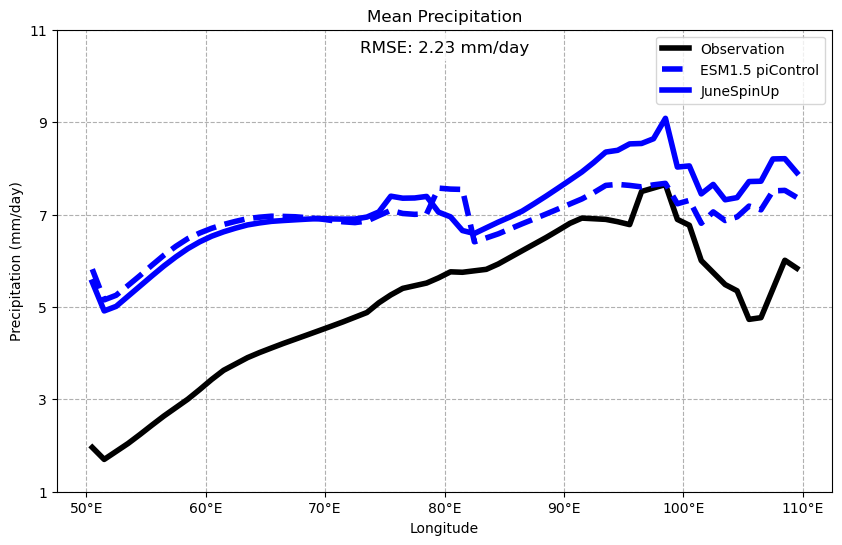

In [15]:
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import numpy as np

# Function to format x-axis labels with degree symbols and N/S
def format_longitude(x, pos):
    if x > 180:
        return f'{int(360 - x)}°W'
    elif x == 180:
        return f'{int(x)}°'
    else:
        return f'{int(x)}°E'

plt.figure(figsize=(10, 6))

obs_data = obs_datasets_prep1["GPCP-SG"]
model_ctrldata = model_ctrldatasets_prep1["ACCESS-ESM1-5"]
model_data = model_datasets_prep1#["ACCESS-ESM1-5"]

# Plot observation data in black
qplt.plot(obs_data, color='black', label='Observation', linewidth=4)

# Plot model data in blue
qplt.plot(model_ctrldata, color='blue', label='ESM1.5 piControl', linewidth=4,linestyle='--')
qplt.plot(model_data, color='blue', label='JuneSpinUp', linewidth=4)

rmse = np.sqrt(np.mean((obs_data.data - model_data.data) ** 2))

# Adding labels and title
plt.xlabel('Longitude')
plt.ylabel('Precipitation (mm/day)')
plt.title('Mean Precipitation')
plt.grid(linestyle='--')
plt.yticks(np.arange(1,12, step=2))

# Adding RMSE text on top of the plot
plt.text(0.5, 0.95, f'RMSE: {rmse:.2f} mm/day', fontsize=12, ha='center', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Setting custom x-axis formatter
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_longitude))

# Adding a legend
plt.legend()

# Display the plot
plt.show()

Figure 1: Zonal bias in the time-mean precipitation (PR) structure across the equatorial Indian Ocean (averaged between 10°S–10°N). The black curve represents the reference data, while the blue curve represents the model data. The metric shown is the zonal RMSE between the model and reference curves.

# Diagnostics Level 2


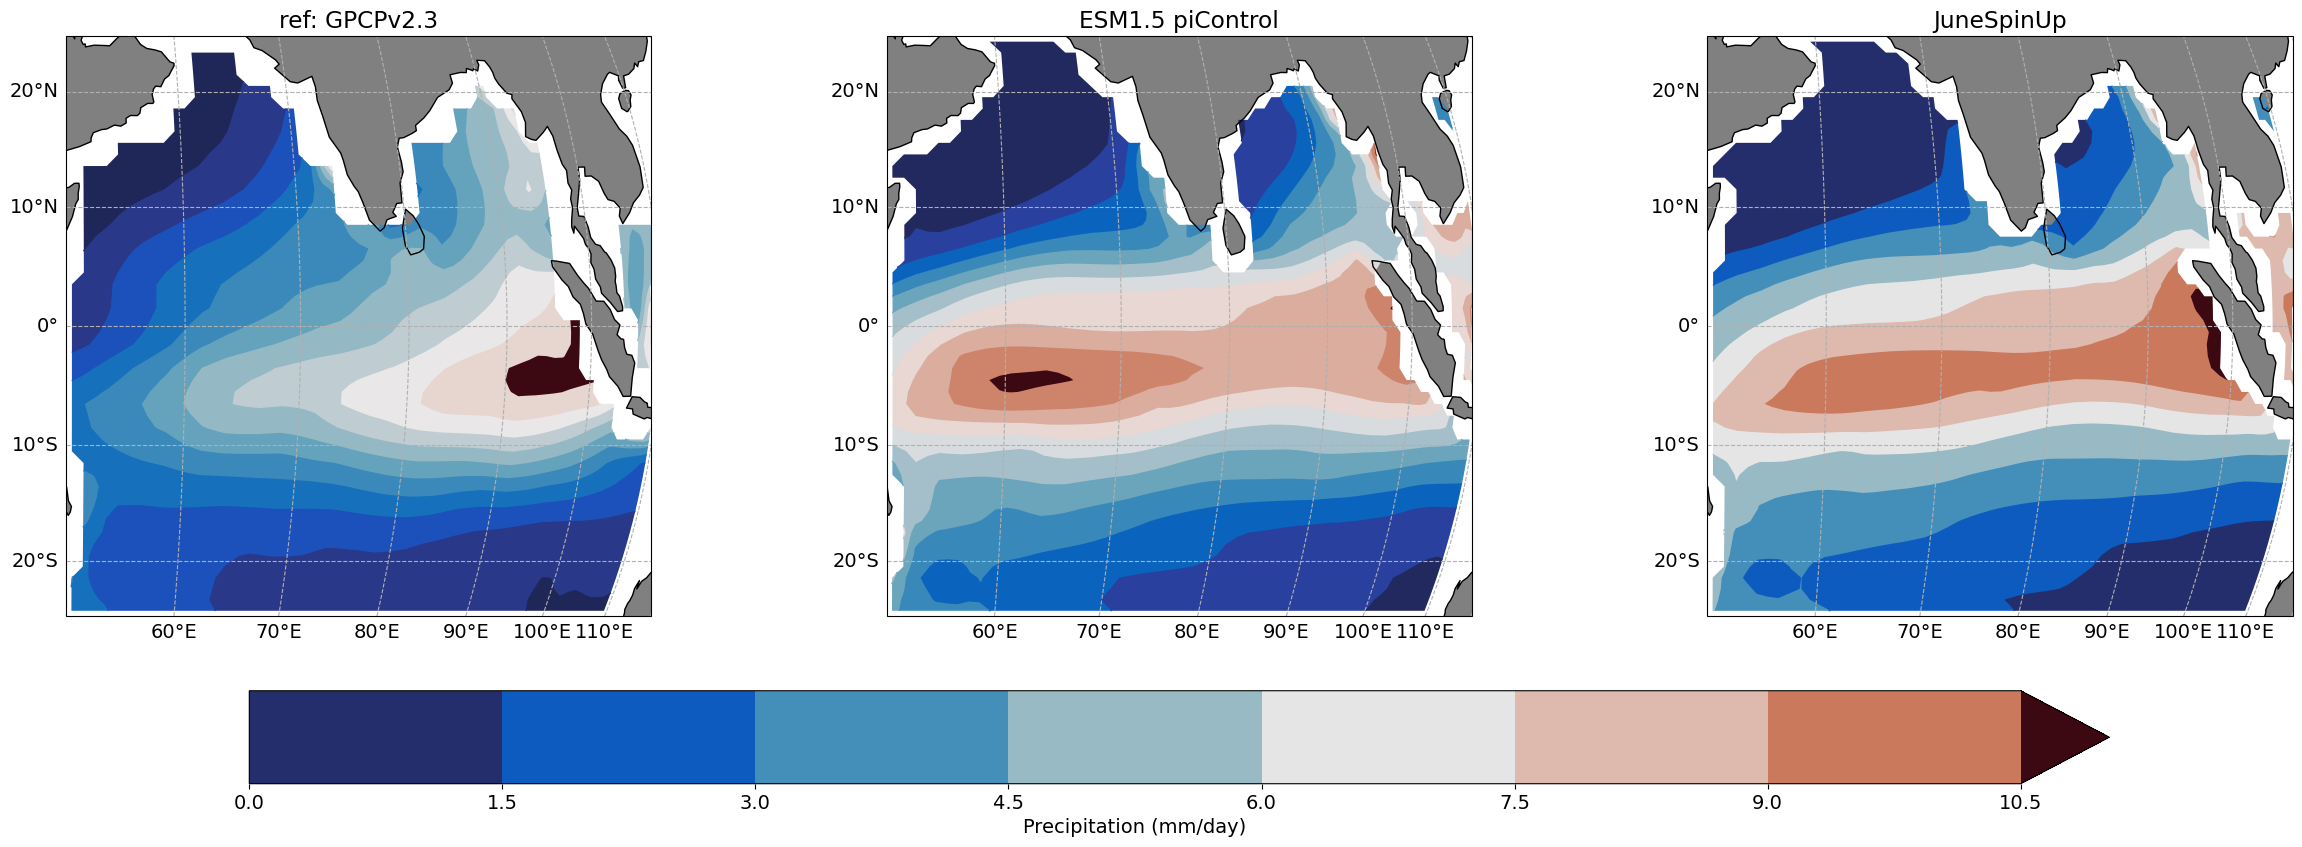

In [25]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as mcolors
import cmocean

# Importing numpy for linear space creation
import numpy as np

import iris
import iris.plot as iplt

obs_data = obs_datasets_prep2["GPCP-SG"]
model_ctrldata = model_ctrldatasets_prep2["ACCESS-ESM1-5"]
model_data = model_datasets_prep2#["ACCESS-ESM1-5"]

# Create a colormap from cmocean balance
cmap = cmocean.cm.balance
# Create a colormap from cmocean balance
vmin=0
vmax=14
colors = cmap(np.linspace(0, 1, 14))
plt.rcParams.update({'font.size': 14})

# Create a large figure
fig = plt.figure(figsize=(30, 10))  # Adjusted for full width

# Center the map on the Indian Ocean (roughly around 180° longitude)
proj = ccrs.Orthographic(central_longitude=50, central_latitude=0)

# Define the normalization for the color scale with range of 0 to 12 mm
norm = mcolors.Normalize(vmin=0, vmax=12)

# Plot #1: contourf for obs data
ax1 = plt.subplot(131, projection=proj)
cf1 = iplt.contourf(obs_data, cmap=cmap, vmin=vmin,vmax=vmax,levels=10,extend='max')
ax1.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax1.coastlines()
ax1.set_extent([50, 110, -25, 25], crs=ccrs.PlateCarree())
ax1.set_title("ref: GPCPv2.3")

# Add gridlines for latitude and longitude
gl1 = ax1.gridlines(draw_labels=True, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False

# Plot #2: contourf for model data
ax2 = plt.subplot(132, projection=proj)
cf2 = iplt.contourf(model_ctrldata, cmap=cmap, vmin=vmin,vmax=vmax,levels=10,extend='max')
ax2.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax2.coastlines()
ax2.set_extent([50, 110, -25, 25], crs=ccrs.PlateCarree())
ax2.set_title("ESM1.5 piControl")

# Add gridlines for latitude and longitude
gl2 = ax2.gridlines(draw_labels=True, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False

# Plot #3: contourf for model data
ax3 = plt.subplot(133, projection=proj)
cf3 = iplt.contourf(model_data, cmap=cmap, vmin=vmin,vmax=vmax,levels=10,extend='max')
ax3.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax3.coastlines()
ax3.set_extent([50, 110, -25, 25], crs=ccrs.PlateCarree())
ax3.set_title("JuneSpinUp")

# Add gridlines for latitude and longitude
gl3 = ax3.gridlines(draw_labels=True, linestyle='--')
gl3.top_labels = False
gl3.right_labels = False

# Add a single colorbar at the bottom
cbar = fig.colorbar(cf3, ax=[ax1, ax2,ax3], orientation='horizontal', pad=0.15, shrink=0.8,extend='max')
cbar.set_label('Precipitation (mm/day)')
#cbar.set_ticks(np.arange(vmin, vmax+2, 2))  # Set ticks at intervals of 2 mm

plt.subplots_adjust(bottom=0.3)  # Further adjust bottom margin to fit the colorbar
plt.show()

Figure 2: Time-mean precipitation (PR) in the equatorial Indian Ocean. The reference data is shown on the left map, and the model data on the right.